In [776]:
import pandas as pd
import numpy as np

In [777]:
df= pd.read_csv("/Users/irem/Downloads/adult income.csv")

In [778]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [779]:
#Above we see missing values coded as "?" not NaN

In [780]:
df = df.replace('?', np.nan)
df= df.dropna()

In [781]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [782]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [783]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [784]:
df.dtypes

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

In [785]:
# Dataset codebook says: 
# "fnlwgt: (continuous, positive integer) Final weight of the record. Basically interpret as the number of people represented by this row." 
# So, the model has to take this as an ordinal column while ranking people's income. 

In [786]:
#There are nominal and ordinal data in the columns, education has no ranking but educational_num has ranking. 

In [787]:
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

numeric_cols = ['age', 'fnlwgt','capital-gain', 'capital-loss', 'hours-per-week']
 
ordinal_columns = ["educational-num"]


#because education is already ordered, numerical values are not ranked inherently
#I dropped education because educational-num is kind of similar to that and I was having trouble to encode eveyrthing seperately
#then also i learned that it is multicollinearity error because these independent variables are related to each other. 
#So, education category is neither necessary nor good for the mddel. 

In [788]:
X = df.drop("income", axis=1)
y = df["income"].to_numpy()
# the model will be using all variables except "income" to estimate income variable.

In [789]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["income"])

#this will turn the income category to binary, 
#<=50K will be 1 and >50K will be 0

In [790]:
from sklearn.preprocessing import OneHotEncoder
nominal_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
).set_output(transform="pandas")

X_nominal_encoded = nominal_encoder.fit_transform(X[nominal_cols])
X_nominal_encoded.head()


,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [791]:
#so above, onehotencoder coded each variable in each nominal columns as a seperate column and attain their binary values. 
#so we coded nominal variables

In [792]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_numeric_scaled = scaler.fit_transform( X[numeric_cols])
# X_numeric_scaled.head() error:  'numpy.ndarray' object has no attribute 'head', 
#so i undetsnd that i need to turn this to a dataframe but i didnt understand why tbh
#but i use StandartScaler to normalize the data because different categories can have more effect on the model ebcause numbers are bigger. 

In [793]:
X_numeric_scaled = pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_cols,
    index=X.index
)
# this is not index in X so i will reassign these to X's numeric columns , then the normalization is solved?
X[numeric_cols] = X_numeric_scaled

In [794]:
X_numeric_scaled.head()

,age,fnlwgt,capital-gain,capital-loss,hours-per-week
0,-1.024983,0.350889,-0.146733,-0.21878,-0.078120
1,-0.041455,-0.945878,-0.146733,-0.21878,0.754701
2,-0.798015,1.393592,-0.146733,-0.21878,-0.078120
3,0.412481,-0.278420,0.877467,-0.21878,-0.078120
5,-0.344079,0.084802,-0.146733,-0.21878,-0.910942


In [795]:
# To replace the categorical colmuns with the encoded ones and scaled numeric ones I will combine them 
# axis=1 as horizontal alignment, if i done it axis=0 it would have added the rows on top of each other
X = pd.concat([X_numeric_scaled, X_nominal_encoded], axis=1, join='outer', ignore_index=False)
#ref: https://medium.com/@whyamit404/understanding-pandas-concat-to-combine-dataframes-41a0abe34cf4

In [796]:
X.head()

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,-1.024983,0.350889,-0.146733,-0.21878,-0.078120,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.041455,-0.945878,-0.146733,-0.21878,0.754701,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.798015,1.393592,-0.146733,-0.21878,-0.078120,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.412481,-0.278420,0.877467,-0.21878,-0.078120,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,-0.344079,0.084802,-0.146733,-0.21878,-0.910942,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [797]:
#Now i have normalized and encoded dataframe and move o with spliting the dataset to trainign and test sets
#ref: classnotes on GitHub

In [798]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [799]:
# Now, we will move on with Task 2: Model Implementation

In [800]:
from sklearn.linear_model import LinearRegression

reg_all = LinearRegression()
reg_all.fit(X_train, y_train)
y_pred = reg_all.predict(X_test)

reg_all.score(X_test, y_test)

#ref: class notes on GitHub

0.34160108369712106

In [801]:
#linear regression in scikit returns R^2, it shows how good the regression model estimates the real values.
#Here it is around 34%, so 34% of the variance in income can be explained by other variables
#ref: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
#ref: https://en.wikipedia.org/wiki/Coefficient_of_determination#:~:text=R2%20is%20a%20measure,predictions%20perfectly%20fit%20the%20data.

In [802]:
import matplotlib.pyplot as plt

In [803]:
from sklearn import tree

clf = tree.DecisionTreeClassifier(max_depth=10)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

y_pred_proba = clf.predict_proba

In [804]:
print('Depth of the Decision Tree :', clf.get_depth())

Depth of the Decision Tree : 10


In [805]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90     10192
           1       0.74      0.60      0.66      3375

    accuracy                           0.85     13567
   macro avg       0.81      0.76      0.78     13567
weighted avg       0.84      0.85      0.84     13567



In [806]:
# so the predicitons of the model is %85 percent accurate

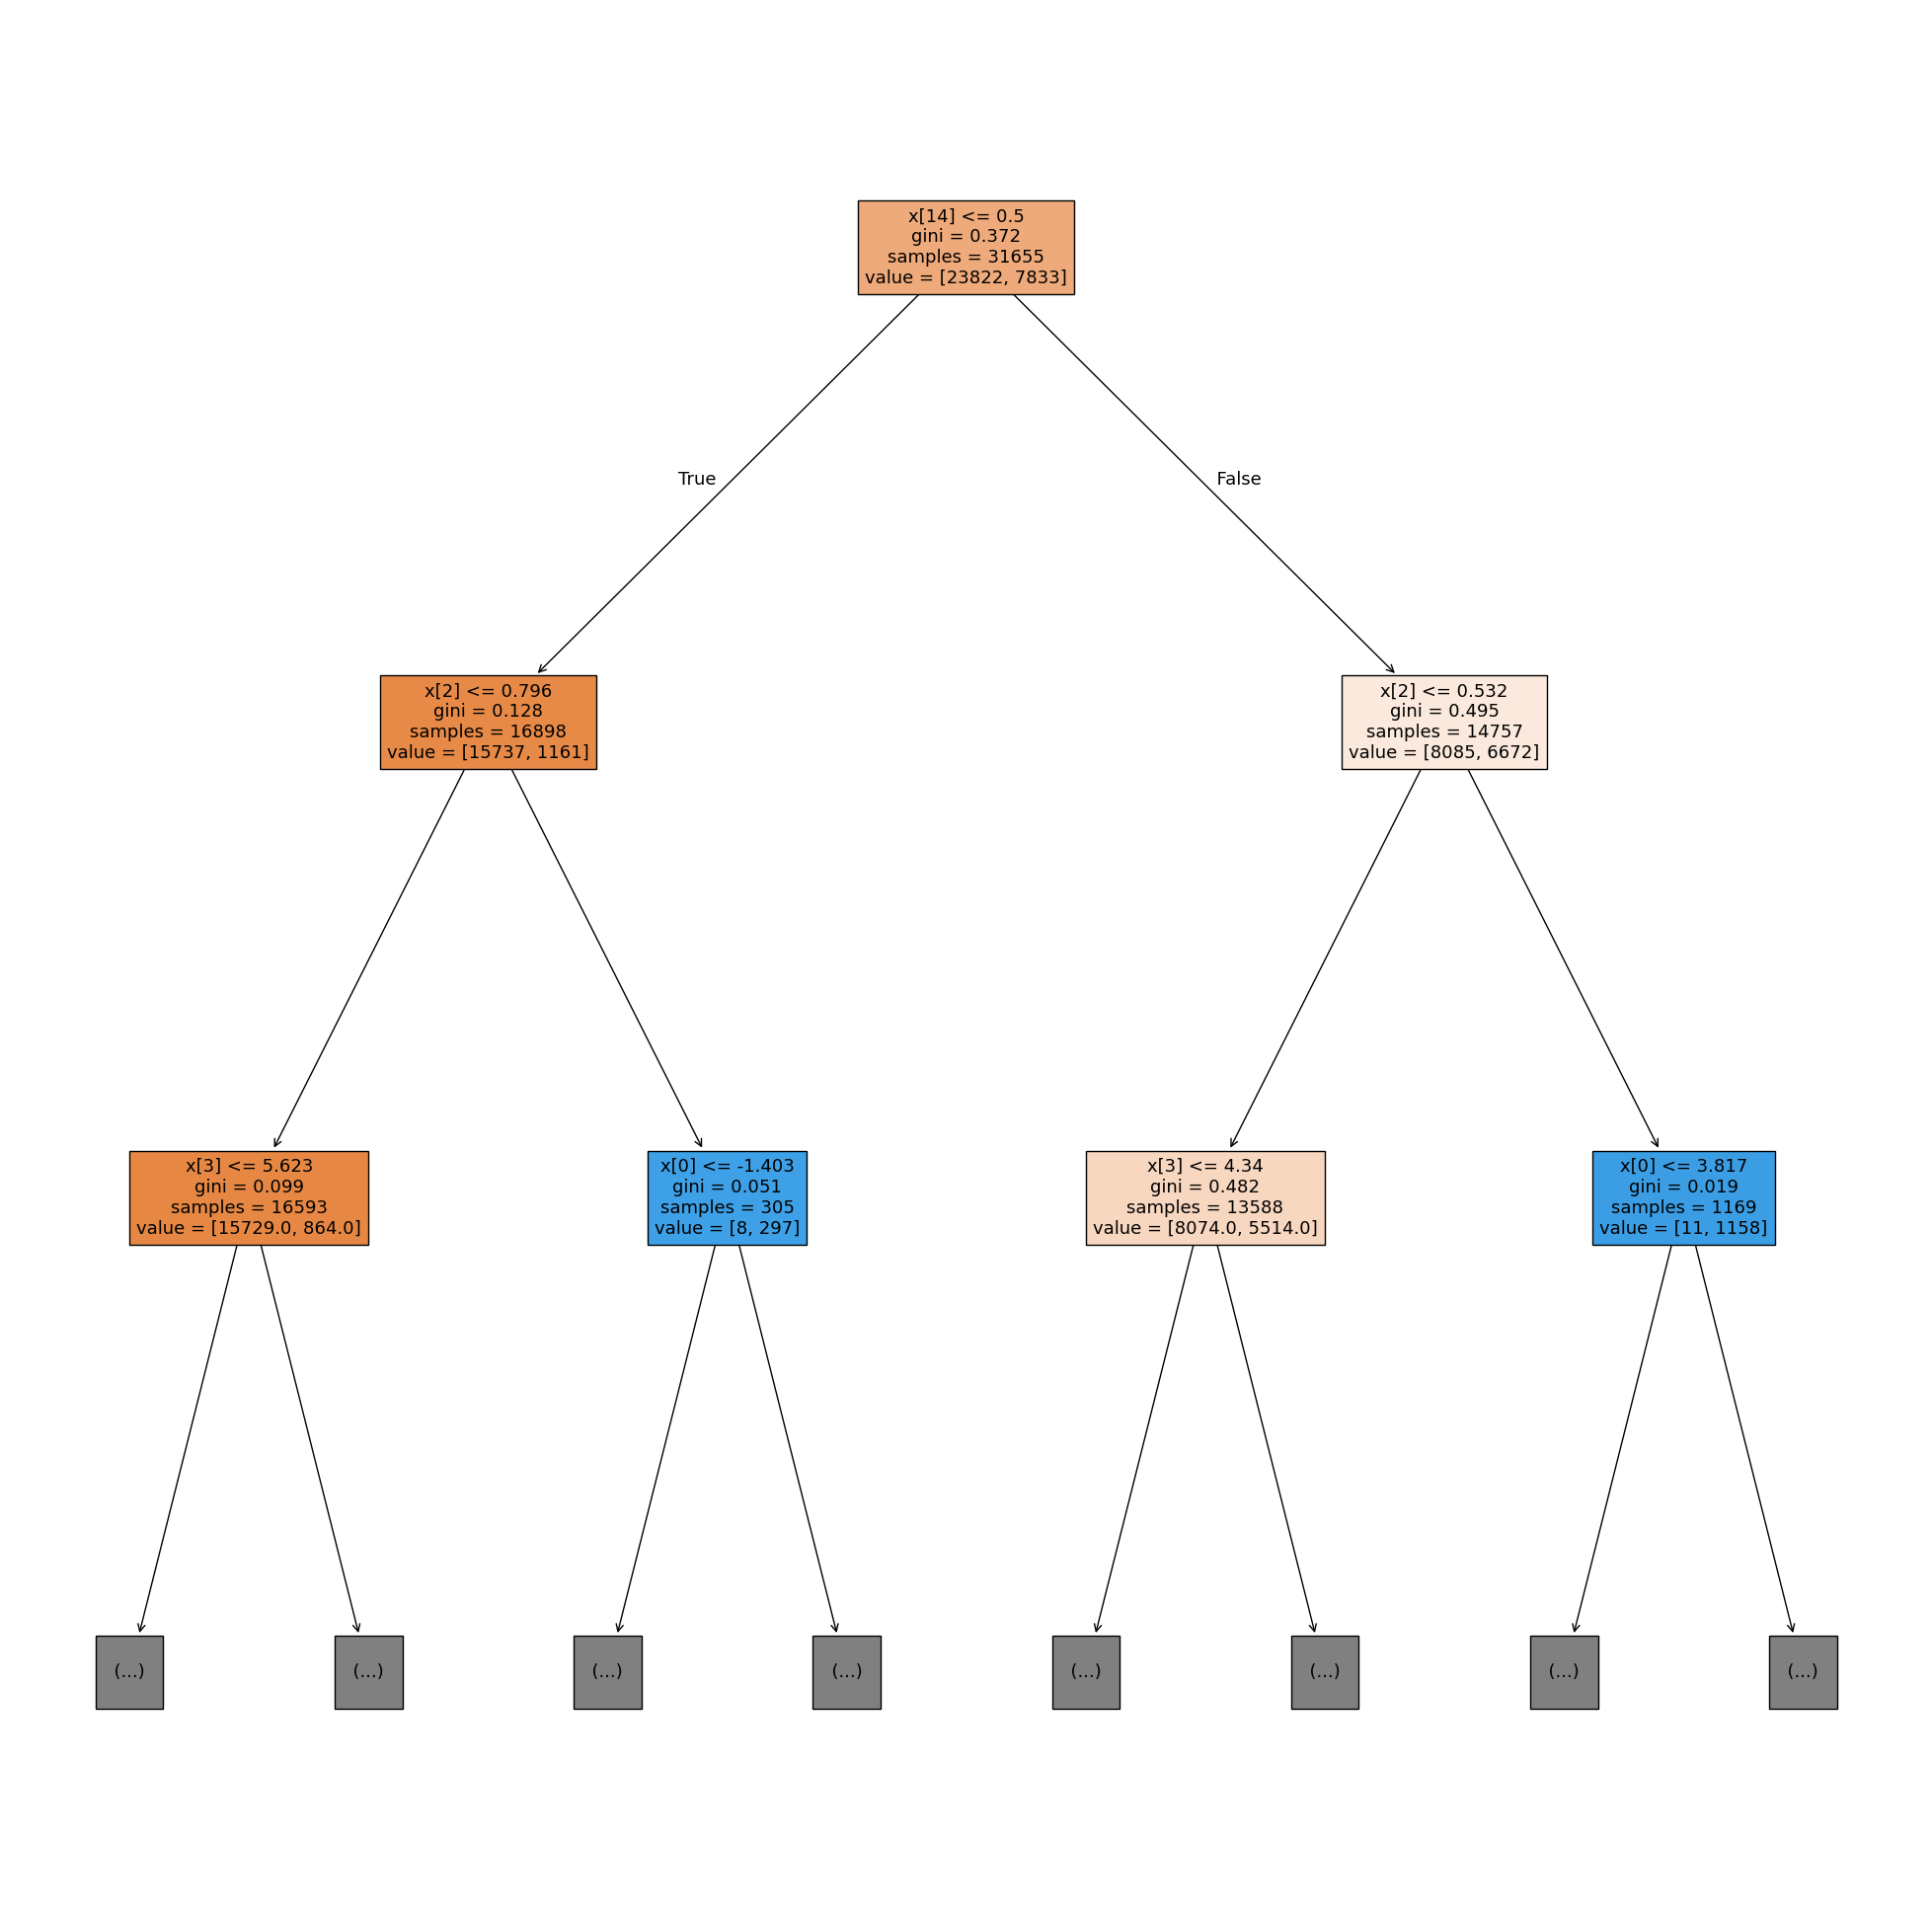

In [807]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,25))
plot_tree(clf, max_depth=2, filled=True)
plt.show()

#ref: GitHub class notes, I addded the max_depth=2 because i wasnt able to read the boxes in its original size

In [808]:
#Above we have decision tree, as the 2.model, now i will do a random forest

In [809]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Number of Trees used : ', clf.n_estimators)

Number of Trees used :  100


In [810]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90     10226
           1       0.72      0.60      0.65      3341

    accuracy                           0.84     13567
   macro avg       0.80      0.76      0.78     13567
weighted avg       0.84      0.84      0.84     13567



In [811]:
# the predicitons of the model is %84 percent accurate. Decision tree was higher. 

In [812]:
# now, we have 3 different models. 

In [813]:
# we will continue with task 3: model tuning. 

In [814]:
from sklearn.model_selection import cross_val_score
reg = LinearRegression()
cv_results = cross_val_score(reg, X, y, cv=5)

print(cv_results)

[0.33740884 0.34422826 0.32319397 0.3407849  0.34843412]


In [815]:
print (cv_results.mean())

0.3388100164381729


In [816]:
#from lineer to ridge regression--regularization
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge.score(X_test, y_test)

0.3444454566380417

In [817]:
#linear regression can have hyperparameter tuning with random search and grid search. 
#and regularization with lasso and ridge. 
#in this part ref: class notes and 
#https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning-in-linear-regression/#1-random-search

In [818]:
#linee to lasso regression--regularization
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso.score(X_test, y_test)

0.0034376119072738742

In [819]:
lasso_coef = lasso.fit(X,y).coef_
print(lasso_coef)
# coeffiencts 0, means those features aare found unimportant by Lasso. 
#positive coefficents means feature increases predicted value
#since there are so many columns after encoding it can be understandble most of them reduced to 0 by Lasso

[ 0.00234467 -0.          0.          0.          0.          0.
  0.         -0.          0.          0.          0.         -0.
 -0.          0.          0.         -0.         -0.         -0.
 -0.         -0.          0.         -0.          0.         -0.
 -0.         -0.         -0.         -0.          0.          0.
  0.          0.         -0.          0.         -0.         -0.
 -0.         -0.          0.         -0.          0.         -0.
 -0.          0.         -0.          0.          0.          0.
  0.         -0.          0.         -0.         -0.         -0.
  0.          0.          0.          0.         -0.         -0.
 -0.         -0.          0.          0.          0.          0.
  0.          0.         -0.          0.         -0.         -0.
 -0.         -0.         -0.          0.         -0.         -0.
 -0.         -0.         -0.          0.         -0.         -0.
  0.         -0.          0.        ]


In [820]:
#hyperparameter tuning for Lasso
param_dist = {'alpha': [0.1, 1.0, 10.0, 100.0]}
lasso = Lasso()
random_search = RandomizedSearchCV(lasso, param_dist, n_iter=10, cv=5)
random_search.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=Lasso(),
                   param_distributions={'alpha': [0.1, 1.0, 10.0, 100.0]})

In [821]:
print("Best alpha:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Best alpha: {'alpha': 0.1}
Best CV R²: 0.003584116880977306


In [822]:
#hyperparameter tuning for Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1.0, 10.0, 100.0]})

In [823]:
print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best alpha: {'alpha': 10.0}
Best CV R²: 0.33778418875813865


In [824]:
from sklearn.linear_model import LinearRegression

reg_all = LinearRegression()
reg_all.fit(X_train, y_train)
y_pred = reg_all.predict(X_test)

reg_all.score(X_test, y_test)

#note: I rewrite this line here again because otherwise y_pred would be the predicted value f the last model which is random forest

0.34160108369712106

In [825]:
# now evaluation for lineer regression, this is part of task 4
from sklearn.metrics import mean_absolute_error, mean_squared_error

#MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

#MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

#RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Absolute Error (MAE): 0.27412166711669494
Mean Squared Error (MSE): 0.12183892777333466
Root Mean Squared Error (RMSE): 0.34905433355472704


In [826]:
#now we will move on with decison tree so i recode the deciison tree below

In [827]:
from sklearn import tree

clf = tree.DecisionTreeClassifier(max_depth=10)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

y_pred_proba = clf.predict_proba

In [828]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [829]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [830]:
from sklearn.metrics import confusion_matrix, accuracy_score
print ("Accuracy score is:", accuracy_score(y_train, y_train_pred))
confusion_matrix(y_train, y_train_pred)

Accuracy score is: 0.8158268835886906


array([[23678,   144],
       [ 5686,  2147]])

In [831]:
#accuracy of decsion tree decreased after model-tuning, now the predictions of the model is 81% accurate
#part of task 4

In [842]:
#now the confusion matrix, i can look at the array but each program writes TP, TN in different rotation so I have to see the table

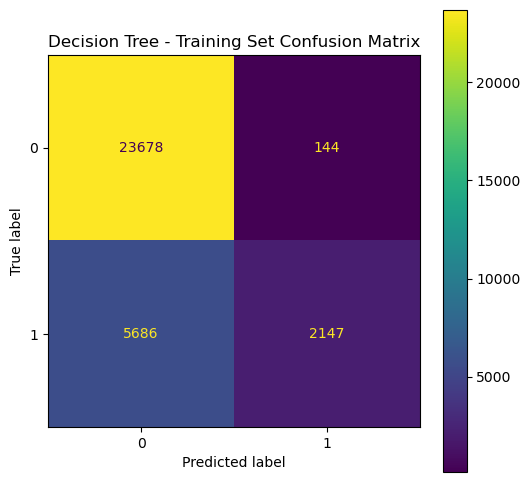

In [843]:
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title("Decision Tree - Training Set Confusion Matrix")
plt.show()


In [844]:
#Here, 23678 is the number of TN, that means the income<=50K and it predicted true
#144 is the number of FP when the true label is <=50K but predicted >50K so overestimation
# 2147 is the number of TP, when the true label is >50K and estimates as such 
# 5686 is the number of FN, when the true label is >50K but predicted <=50K so underestimation
#So, the decision tree model is doing more underestimation then overestimation, so it is better at estimating the lowincoem by far, 144<5686

In [853]:
#model evaluation: Linear regression has a highest R^2 among ridge and lasso

In [854]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Number of Trees used : ', clf.n_estimators)

Number of Trees used :  100


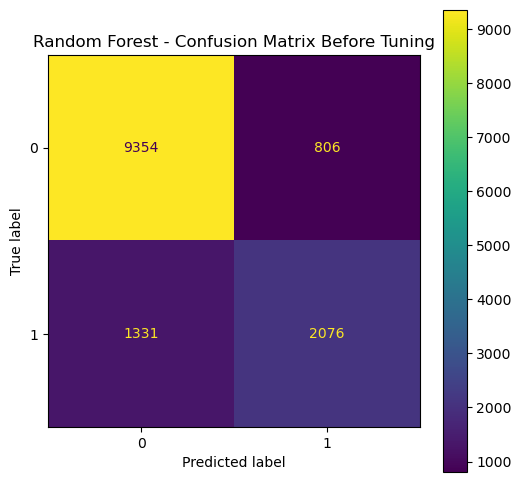

In [855]:
cm_rf = confusion_matrix(y_test, y_pred)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(6,6))
disp_rf.plot(ax=ax)
plt.title("Random Forest - Confusion Matrix Before Tuning")
plt.show()

In [856]:
#I didnt do tuning on random forest but decision tree has the higher accuracy score before tuning, their weighted F1 score was same
#before tuning the confusion matrix of random forest has numbers that are closer to each other. but it has less true predictions than decision tree. 